INFO:__main__:Data loaded successfully
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/noah/anaconda3/envs/dski_ml/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

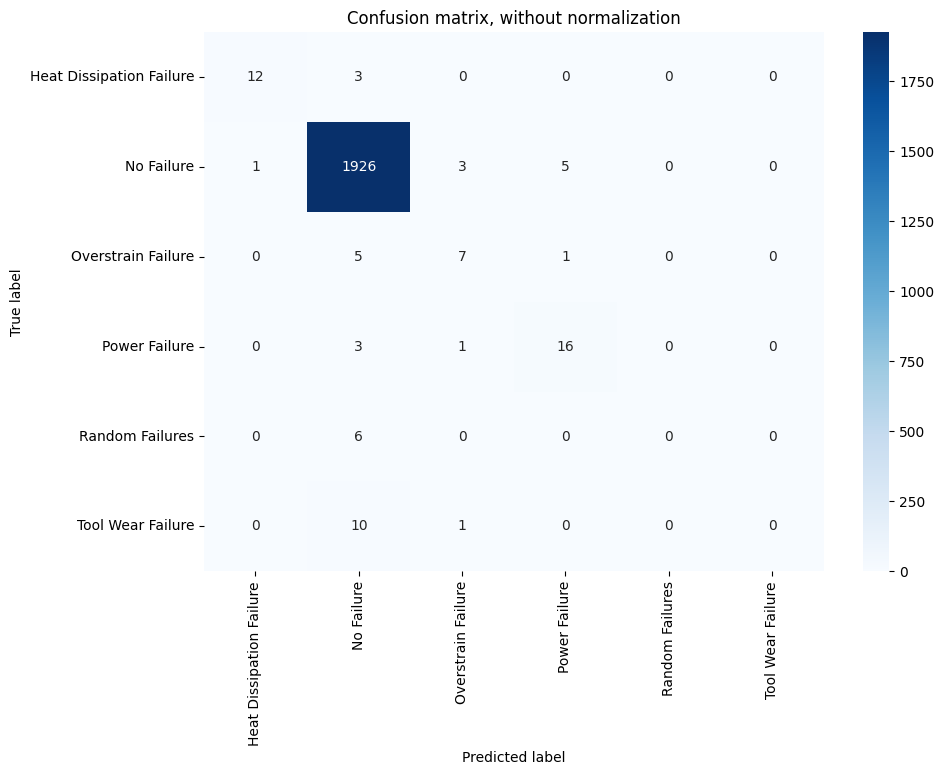

INFO:__main__:Normalized confusion matrix


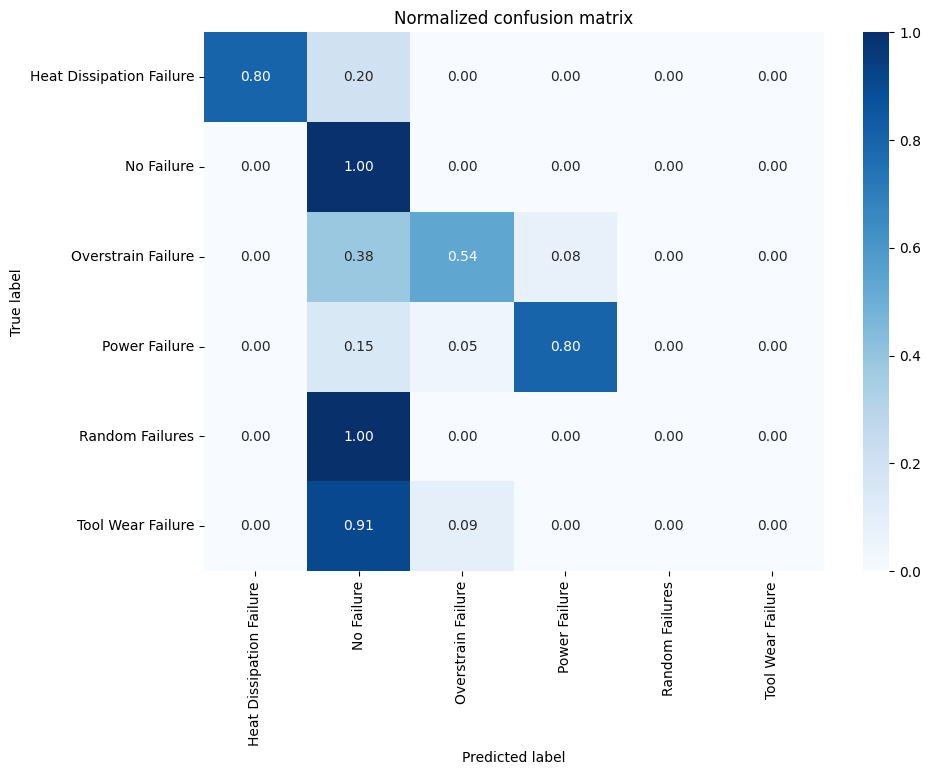

INFO:__main__:
All Model Results:
INFO:__main__:                                              params  mean_test_score  \
1  {'classifier': GradientBoostingClassifier(), '...            0.981   
0  {'classifier': RandomForestClassifier(), 'clas...            0.980   

   std_test_score  rank_test_score  
1        0.000986                1  
0        0.000180                2  
INFO:__main__:
Model 1: {'classifier': RandomForestClassifier(max_depth=10), 'classifier__max_depth': 10, 'classifier__n_estimators': 100}
INFO:__main__:Confusion matrix, without normalization


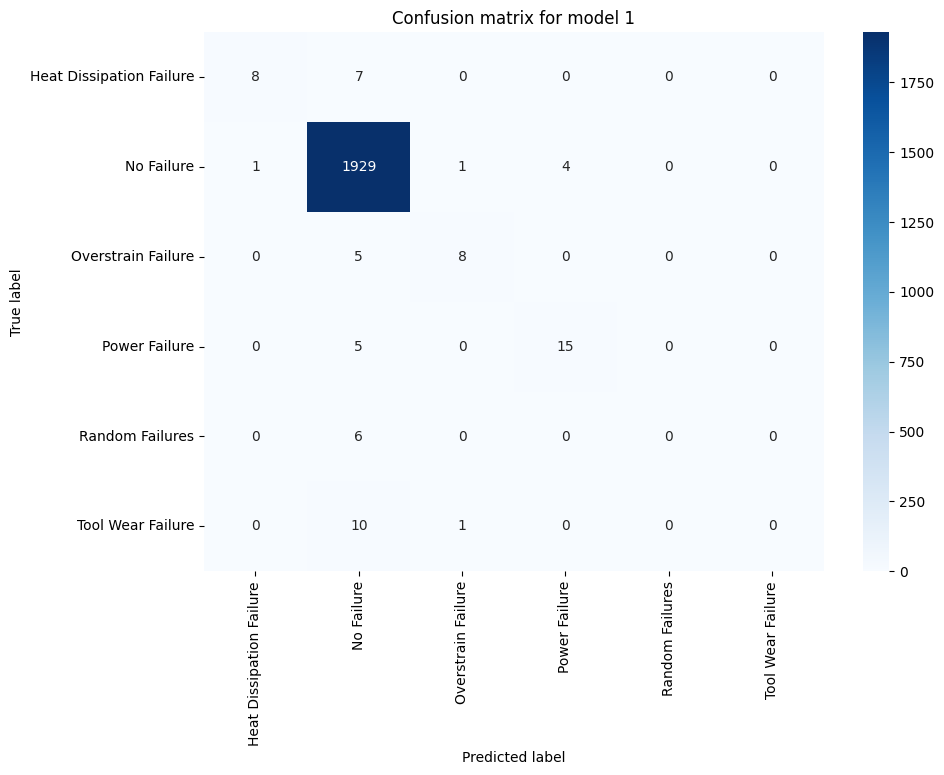

INFO:__main__:Normalized confusion matrix


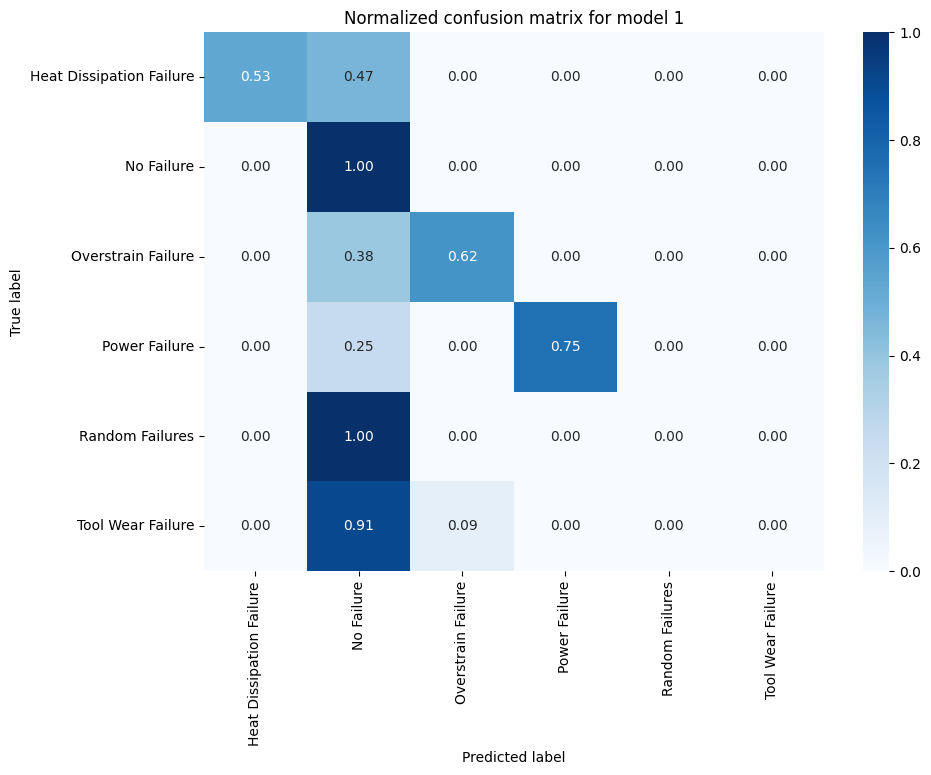

INFO:__main__:
Model 2: {'classifier': GradientBoostingClassifier(), 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
INFO:__main__:Confusion matrix, without normalization


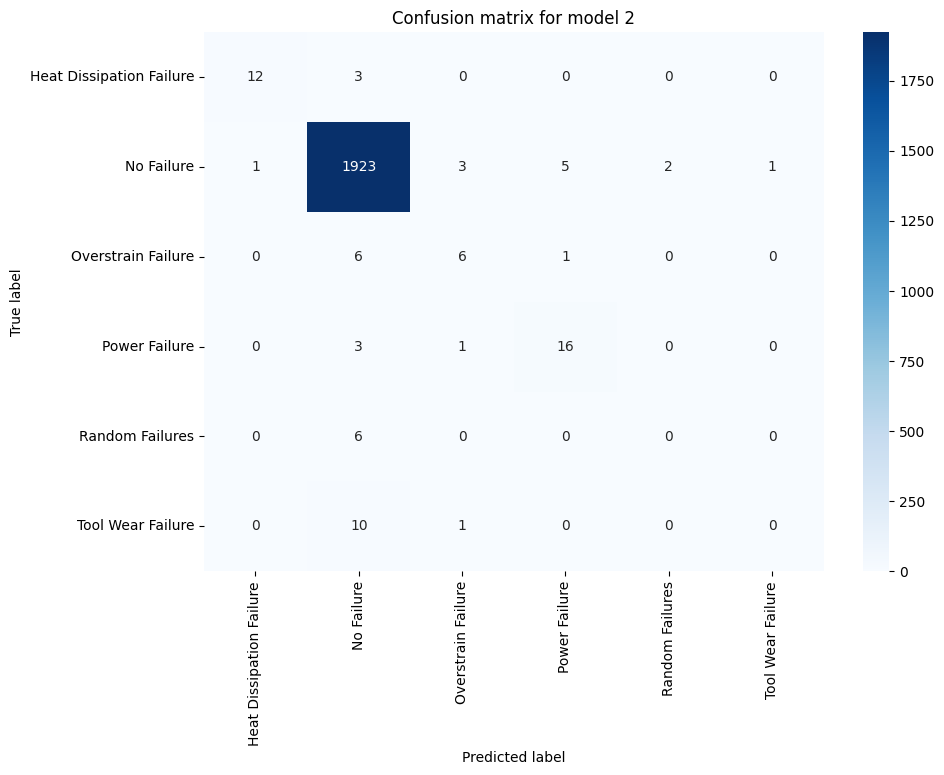

INFO:__main__:Normalized confusion matrix


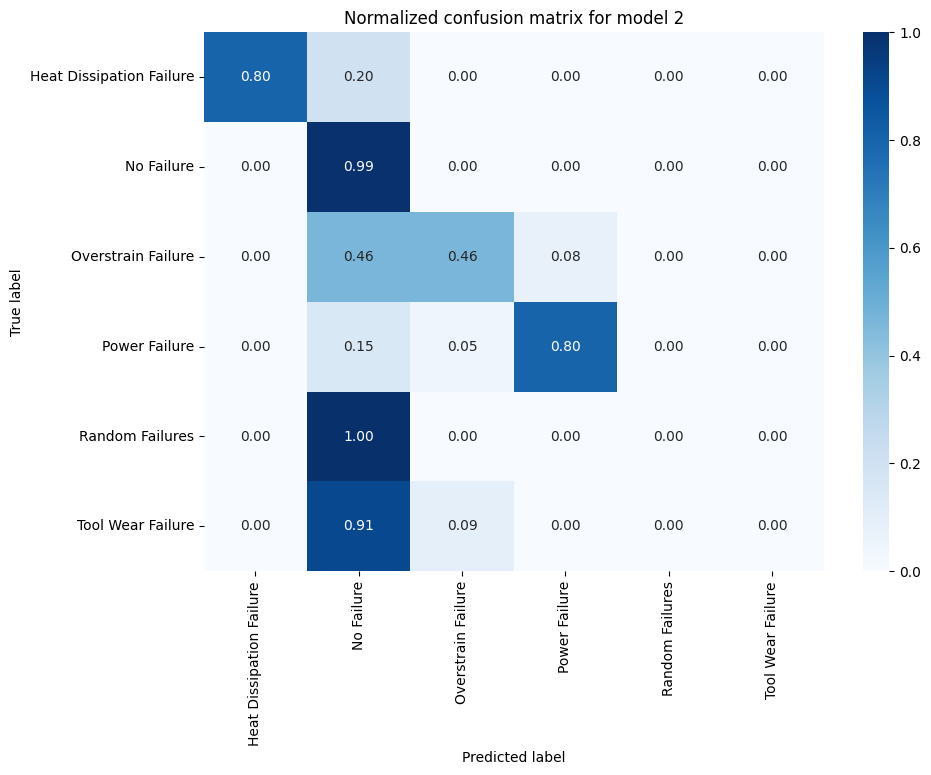

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import logging
import mlflow
import mlflow.sklearn

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Load the data
file_path = "../../data/predictive_maintenance.csv"
data = pd.read_csv(file_path)

# Log data loading
logger.info("Data loaded successfully")

# Define feature columns and target column
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
target = 'Failure Type'

# Split data into features and target
X = data[features]
y = data[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features)
    ]
)

# Define the parameter grid for hyperparameter tuning
param_grid = [
    {
        'classifier': [RandomForestClassifier()],
        'classifier__n_estimators': [100],
        'classifier__max_depth': [10]
    },
    {
        'classifier': [GradientBoostingClassifier()],
        'classifier__n_estimators': [100],
        'classifier__learning_rate': [0.1],
        'classifier__max_depth': [3]
    }
]

# Create the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())  # Placeholder, will be overwritten by GridSearchCV
])

# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=3, n_jobs=-1)

# Use MLflow to log experiments
mlflow.start_run()

# Fit the model
grid_search.fit(X_train, y_train)

# Log the best parameters and estimator
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
mlflow.log_params(best_params)
mlflow.sklearn.log_model(best_model, "model")

# Evaluate the best model
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

mlflow.log_metric("accuracy", accuracy)
logger.info("Best Model Accuracy: %s", accuracy)
logger.info("Best Model Classification Report:\n %s", classification_rep)

# Plotting confusion matrix for the best model
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues, normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        logger.info("Normalized confusion matrix")
    else:
        logger.info('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap, 
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

# Plot non-normalized confusion matrix
plot_confusion_matrix(cnf_matrix, classes=np.unique(y), title='Confusion matrix, without normalization')

# Plot normalized confusion matrix
plot_confusion_matrix(cnf_matrix, classes=np.unique(y), title='Normalized confusion matrix', normalize=True)

# Get results for all models tried during the grid search
results = pd.DataFrame(grid_search.cv_results_)

# Display the relevant columns for all models
results_summary = results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
results_summary = results_summary.sort_values(by='rank_test_score')

logger.info("\nAll Model Results:")
logger.info(results_summary)

# Optionally, save the results to a CSV file for further analysis
results_summary.to_csv('grid_search_results.csv', index=False)
mlflow.end_run()

# Evaluate all models and print their confusion matrices
for i, params in enumerate(grid_search.cv_results_['params']):
    model = grid_search.estimator.set_params(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cnf_matrix = confusion_matrix(y_test, y_pred)
    
    logger.info(f"\nModel {i + 1}: {params}")
    plot_confusion_matrix(cnf_matrix, classes=np.unique(y), title=f'Confusion matrix for model {i + 1}', normalize=False)
    plot_confusion_matrix(cnf_matrix, classes=np.unique(y), title=f'Normalized confusion matrix for model {i + 1}', normalize=True)
